# 実行例5.1 ETL1手書き数字データベースの最近傍法による識別（p.57図5.4,図5.5）

- `Images`,`Colors` : ETL1ファイル読み込み用
- `ImageView` : サンプル表示用
- `StringEncodings` : JIS X 0201→UTF8変換用
- `ImageFiltering` : 画像を滑らかにするためのカーネル畳み込み用
- `ImageTransformations`,`Interpolations` : 画像のリサイズ用

In [1]:
using Pkg
Pkg.activate(@__DIR__)
using Statistics
using LinearAlgebra
using DataFrames
using CairoMakie
using Images
using Colors
using ImageView
using StringEncodings
using ImageFiltering
using ImageTransformations
using Interpolations

  Activating project at `c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


## Ⅰ　ETL1データの前処理

### 1. フィールドデータの抽出コード
- Claude作成コード
- 手書き文字が何を示しているのか識別した結果は`ascii`や`jis_code`になっている。

In [2]:
struct ETL1Record
    data_number::UInt16
    char_code::UInt16
    sheet_number::UInt16
    jis_code::UInt8
    ebcdic_code::UInt8
    eval_individual::UInt8
    eval_group::UInt8
    mat::Matrix{UInt8}
    image::Matrix{Gray{N0f8}}
end

function read_etl1(filepath)
    records = ETL1Record[]
    record_size = 2052
    
    open(filepath, "r") do f
        while !eof(f)
            data = read(f, record_size)
            length(data) < record_size && break
            
            # ヘッダ（ビッグエンディアン）
            data_number   = ntoh(reinterpret(UInt16, data[1:2])[1])
            char_code     = ntoh(reinterpret(UInt16, data[3:4])[1])
            sheet_number  = ntoh(reinterpret(UInt16, data[5:6])[1])
            jis_code      = data[7]
            ebcdic_code   = data[8]
            eval_individual = data[9]
            eval_group    = data[10]
            
            # 画像データ: 4bpp → 8bpp展開
            img_raw = data[33:2048]
            pixels = UInt8[]
            for byte in img_raw
                push!(pixels, (byte >> 4) * 17)
                push!(pixels, (byte & 0x0F) * 17)
            end
            
            # 63×64にreshape（行優先）してGray画像に
            mat = transpose(reshape(pixels[1:63*64], 64, 63))
            img = Gray{N0f8}.(mat ./ 255)   # 256階調のグレースケール
            # img = Gray{Bool}.(mat .> 128)   # 2値化
            
            push!(records, ETL1Record(
                data_number, char_code, sheet_number,
                jis_code, ebcdic_code, eval_individual, eval_group,
                mat, img
            ))
        end
    end
    
    return records
end

read_etl1 (generic function with 1 method)

- `struct`でフィールドごとの型を指定することでき、全体をまとめて型として定義できる。
- エンディアン（endian） : 2バイト以上のデータをメモリに置く場合の並び順（ビッグエンディアンは最初のバイトから並べ、リトリエンディアンは最後のバイトから並べる）
- `ntoh()` : ETL1のファイルはビッグエンディアン（上位バイトが先）で格納されているのに対しPCのCPU（x86）はリトルエンディアン（下位バイトが先）になっているため格納順を並び替える。
- `reinterpret()` : バイナリを符号なし整数（UInt）や浮動小数点（Float）などに再解釈する。UTFへの変換する場合は別途`Char()`や`String()`が必要。
- `(byte >> 4) * 17` : 各バイトの上位4ビットを取り出して17倍（0-15を0-255に変換）　※1バイトに2ピクセル分（4ビット×2）が詰まっている。
- `(byte & 0x0F) * 17` : 各バイトの下位4ビットを取り出して17倍（0-15を0-255に変換）　※1バイトに2ピクセル分（4ビット×2）が詰まっている。
- `byte = 0xA3（1010 0011）`の場合
    - `byte >> 4` : 右に4ビットシフト → 0000 1010 = 10（上位4ビットを取り出す）
    - `byte & 0x0F` : 0x0F=0000 1111とAND → 0000 0011 = 3（下位4ビットを取り出す）
- `Gray{N0f8}.(...)` : 各値をグレースケールのピクセル型に変換
- `mat ./ 255` : 0-255の値を0.0-1.0に正規化
- `Gray{Bool}.(...)` : 各値を2値のピクセル型に変換
- `mat .> 128` : 128より大きければtrue（白）、小さければfalse（黒）

### 2. ETL1ファイル読み込み

#### 2.1 ファイルのデータを`records`に変換

In [3]:
# (1)ファイルパスの指定
filepath = joinpath(@__DIR__, "ETL1C_01")

# (2)ファイルの読み込み
records = read_etl1(filepath)

11560-element Vector{ETL1Record}:
 ETL1Record(0x0001, 0x3020, 0x03e9, 0x30, 0xf0, 0x00, 0x00, UInt8[0x22 0x11 … 0x11 0x11; 0x11 0x11 … 0x22 0x11; … ; 0x11 0x11 … 0x11 0x11; 0x11 0x11 … 0x11 0x11], Gray{N0f8}[0.133 0.067 … 0.067 0.067; 0.067 0.067 … 0.133 0.067; … ; 0.067 0.067 … 0.067 0.067; 0.067 0.067 … 0.067 0.067])
 ETL1Record(0x0002, 0x3020, 0x03ea, 0x30, 0xf0, 0x00, 0x00, UInt8[0x11 0x00 … 0x11 0x11; 0x11 0x11 … 0x11 0x11; … ; 0x11 0x11 … 0x11 0x11; 0x11 0x11 … 0x11 0x00], Gray{N0f8}[0.067 0.0 … 0.067 0.067; 0.067 0.067 … 0.067 0.067; … ; 0.067 0.067 … 0.067 0.067; 0.067 0.067 … 0.067 0.0])
 ETL1Record(0x0003, 0x3020, 0x03eb, 0x30, 0xf0, 0x01, 0x00, UInt8[0x22 0x11 … 0x11 0x11; 0x11 0x11 … 0x11 0x11; … ; 0x11 0x11 … 0x11 0x11; 0x11 0x22 … 0x11 0x11], Gray{N0f8}[0.133 0.067 … 0.067 0.067; 0.067 0.067 … 0.067 0.067; … ; 0.067 0.067 … 0.067 0.067; 0.067 0.133 … 0.067 0.067])
 ETL1Record(0x0004, 0x3020, 0x03ec, 0x30, 0xf0, 0x00, 0x00, UInt8[0x11 0x11 … 0x11 0x11; 0x11 0x11 … 0x11 0x1

#### 【テスト】読み込んだサンプルの表示

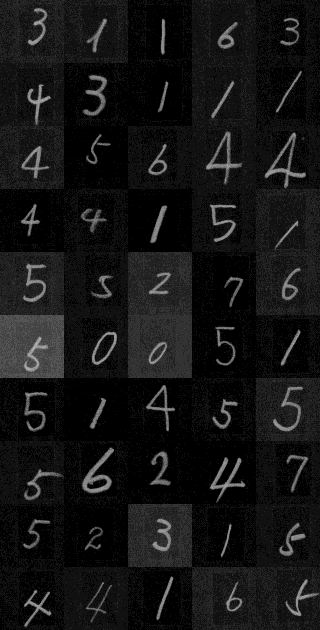

['3', '4', '4', '4', '5', '5', '5', '5', '5', '4', '1', '3', '5', '4', '5', '0', '1', '6', '2', '4', '1', '1', '6', '1', '2', '0', '4', '2', '3', '1', '6', '1', '4', '5', '7', '5', '5', '4', '1', '6', '3', '1', '4', '1', '6', '1', '5', '7', '5', '5']
["3", "4", "4", "4", "5", "5", "5", "5", "5", "4", "1", "3", "5", "4", "5", "0", "1", "6", "2", "4", "1", "1", "6", "1", "2", "0", "4", "2", "3", "1", "6", "1", "4", "5", "7", "5", "5", "4", "1", "6", "3", "1", "4", "1", "6", "1", "5", "7", "5", "5"]


In [4]:
# (1)表示するサンプル数
num_sample = 50

# (2)ランダムでサンプル取得
# 型指定
record_sample = ETL1Record[]
# サンプル取得
for i in 1:num_sample
    push!(record_sample, records[rand(1:length(records))])
end

# (3)個別のウィンドウで画像データ表示
# ⚠サンプルの数だけウィンドウが開く
# for i in 1:num_sample
#     println("JIS: 0x", string(record_sample[i].jis_code, base=16, pad=4))
#     imshow(records[i].image)
#     sleep(1)  # 1枚ずつ確認
# end

# (4)グリッドにまとめて画像データ表示
samples = [record_sample[i].image for i in 1:num_sample]
classes_ascii = [record_sample[i].char_code for i in 1:num_sample]
calsses_jis = [record_sample[i].jis_code for i in 1:num_sample]
mosaic_sample = mosaicview(samples..., nrow=10, ncols=5, fillvalue=Gray(1))
# imshow(mosaic)
display(collect(mosaic_sample))

# (5)ASCIIとJIS X 0201で画像の種別の確認
println([Char(c_askii >> 8)  for c_askii in classes_ascii])
println([decode([c_jis],"X0201") for c_jis in calsses_jis])

# (6)サンプルを保存
# save("etl1_sample.png", mosaic_sample)

- `Char(c_askii >> 8)` : ASCIIからUTF-8に変換
- `decode([c_jis],"X0201")` : JIS X 0201からUTF-8に変換（`StringEncodings.jl`の関数）
- 通常の画像データは`Matrix`型で変数だけで表示されるが`MosaicView`型は特殊なため一工夫要る。`collect()`で実体化（配列化）して、それでも表示されない場合は`display()`で明示的に表示させる。

### 3. 画像の正規化

#### 3.1 手書き文字の切り抜きと位置ズレの補正

In [5]:
# (1)グレースケール状態での手書き部分の切り抜き（正方形）
function img_cutting_grey(img)
    # ①手書き位置の確認
    # 一番端のピクセル位置の初期化
    p_top, p_bottom, p_left, p_right = 63, 1, 64, 1
    # 手書き文字と認識する閾値の設定
    p_threshold = 0.5
    # 一番端のピクセル位置の探索
    for i in 1:63
        for j in 1:64
            if img[i, j] > p_threshold
                if i < p_top
                    p_top = i
                elseif i > p_bottom
                    p_bottom = i
                end
                
                if j < p_left
                    p_left = j
                elseif j > p_right
                    p_right = j
                end
            end
        end
    end
    # 【テスト】上下左右の端の位置の確認
    # println(p_top, ":", p_bottom, ":", p_left, ":", p_right)

    # ②切り抜きサイズの確認
    # 上下と左右の幅の広さを比較
    # 文字の書かれている箇所を正方形で切り抜くための辺の長さの確認
    square_cut = 0
    # 文字の位置ずれを補正
    shift_width, shift_hight = 0, 0
    if (p_bottom - p_top) > (p_right - p_left)
        square_cut = p_bottom - p_top
        shift_width = ((p_bottom - p_top) - (p_right - p_left)) ÷ 2
    else
        square_cut = p_right - p_left
        shift_hight = ((p_right - p_left) - (p_bottom - p_top)) ÷ 2
    end

    # ③切り抜くにあたって長さが足りないところを黒いピクセルで埋めておく
    # 元の画像サイズ
    h, w = size(img)  # 63, 64
    # 長手方向の長さ
    height = p_bottom - p_top
    width = p_right - p_left
    square = max(height, width)
    # 必要なパディング量
    pad_bottom = max(0, p_top + square - h)
    pad_right  = max(0, p_left + square - w)
    # 黒ピクセルでパディング
    new_h = h + pad_bottom
    new_w = w + pad_right
    padded = fill(Gray{N0f8}(0), new_h, new_w)  # グレースケールでパディング
    padded[1:h, 1:w] = img

    # ④正方形に切り抜き
    cutting_image = padded[p_top - shift_hight:p_top + square_cut, p_left - shift_width : p_left + square_cut]

    return cutting_image, square    # 切り抜き結果の画像、画像の辺の長さ
end

# (2)オリジナル状態での手書き部分の切り抜き（正方形）
function img_cutting_mat(mat::Matrix{UInt8})
    # ①手書き位置の確認
    # 一番端のピクセル位置の初期化
    p_top, p_bottom, p_left, p_right = 63, 1, 64, 1
    # 手書き文字と認識する閾値の設定
    p_threshold = 128
    # 一番端のピクセル位置の探索
    for i in 1:63
        for j in 1:64
            if mat[i, j] > p_threshold
                if i < p_top
                    p_top = i
                elseif i > p_bottom
                    p_bottom = i
                end
                
                if j < p_left
                    p_left = j
                elseif j > p_right
                    p_right = j
                end
            end
        end
    end
    # 【テスト】上下左右の端の位置の確認
    # println(p_top, ":", p_bottom, ":", p_left, ":", p_right)

    # ②切り抜きサイズの確認
    # 上下と左右の幅の広さを比較
    # 文字の書かれている箇所を正方形で切り抜くための辺の長さの確認
    square_cut = 0
    # 文字の位置ずれを補正
    shift_width, shift_hight = 0, 0
    if (p_bottom - p_top) > (p_right - p_left)
        square_cut = p_bottom - p_top
        shift_width = ((p_bottom - p_top) - (p_right - p_left)) ÷ 2
    else
        square_cut = p_right - p_left
        shift_hight = ((p_right - p_left) - (p_bottom - p_top)) ÷ 2
    end

    # ③切り抜くにあたって長さが足りないところを黒いピクセルで埋めておく
    # 元の画像サイズ
    h, w = size(mat)  # 63, 64
    # 長手方向の長さ
    height = p_bottom - p_top
    width = p_right - p_left
    square = max(height, width)
    # 必要なパディング量
    pad_bottom = max(0, p_top + square - h)
    pad_right  = max(0, p_left + square - w)
    # 黒ピクセルでパディング
    new_h = h + pad_bottom
    new_w = w + pad_right
    padded = fill(UInt8(0), new_h, new_w)   # オリジナル状態でパディング
    padded[1:h, 1:w] = mat

    # ④正方形に切り抜き
    cutting_mat = padded[p_top - shift_hight:p_top + square_cut, p_left - shift_width : p_left + square_cut]

    return cutting_mat, square    # 切り抜き結果の画像、画像の辺の長さ
end
    

img_cutting_mat (generic function with 1 method)

- img[i, j]のiは行（上下方向）、jは列（左右方向）
- `÷` : 商だけ取る。`\div`でtab変換できる。`Int()`は型変換だけで小数点には使えない。
- `round(Int, x)`,`floor(Int, x)`,`ceil(Int, x)` : それぞれ四捨五入、切り捨て、切り上げ

#### 【テスト】切り抜きの確認

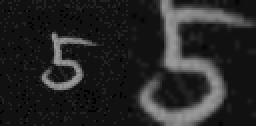

In [6]:
# 対象サンプル
n = 8249
# 切り抜き
cutting_image = img_cutting_grey(records[n].image)[1]   # グレースケールの切り抜き
cutting_mat = img_cutting_mat(records[n].mat)[1]    # オリジナルで切り抜き
# imshow(records[n].image)
# save("etl1_no_cutting.png", records[n].image)
# imshow(cutting_image)
# save("etl1_cutting.png", cutting_image)
# img出力用加工
output_image = imresize(cutting_image, size(records[n].image))
[records[n].image output_image]
# [records[n].image ; resize_image]

- 画像データを[]で配列するとアウトプットセルに並べて表示できる。半角スペースなら横並び、`;`を使えば縦並び（通常の配列と同じ）
- ただし並べるデータのサイズを揃える必要があり、`resize_image = imresize(cutting_image, size(records[n].image))`で処理している。

#### 3.2 リサイズ
- `imresize()`を使って切り出した画像を`16×16ピクセルにサイズ変更する。
- `imresize()` : `ImageTransformations.jl`の関数
- `BSpline` : `Interpolations.jl`の関数
- `Cubic()`は浮動小数点しか扱えないので引数はグレースケールの`img`ではなくオリジナルの`mat`を使用する。

In [7]:
img = cutting_mat
img_f = float.(channelview(img))
@show typeof(img_f)  # Gray{Float64}になっているか確認

typeof(img_f) = Matrix{Float64}


Matrix{Float64} (alias for Array{Float64, 2})

In [8]:
# (1) リサイズ
function img_resize(mat::Matrix{UInt8}, alg=1)
    #=
    mat⇒
    alg⇒
        1:Bicubic
        2:Bilinear
        3:Nearest neighbor
    =#
    
    if alg == 1
        resized_image = imresize(mat, (16, 16), method=BSpline(Cubic(Line(OnGrid()))))
    elseif alg == 2
        resized_image = imresize(mat, (16, 16), method=BSpline(Linear()))
    elseif alg == 3
        resized_image = imresize(mat, (16, 16), method=BSpline(Constant()))
    else
        resized_image = mat
    end

    return resized_image
end

img_resize (generic function with 2 methods)

#### 【テスト】リサイズの確認

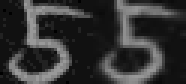

In [9]:
# リサイズ手法の指定
#=
alg⇒
    1:Bicubic
    2:Bilinear
    3:Nearest neighbor
=#
alg = 1
# 切り抜き画像を指定
#=
arg⇒::Matrix{UInt8}
=#
mat = cutting_mat
# リサイズ
resized_mat = img_resize(mat, alg) 
# 出力用加工
resize_image = imresize(Gray{N0f8}.(resized_mat ./ 255), size(cutting_image))
[cutting_image resize_image]

#### 3.3 フィルター処理
- フィルター用のカーネルを準備して、`imfilter()`で処理をする。
- `imfilter()` : `ImageFiltering.jl`の関数

In [10]:
# (1) ガウシアンフィルター
# ガウシアンカーネル
function gaussian_kernel(size, sigma)
    k = zeros(size, size)
    c = size ÷ 2 + 1
    for i in 1:size
        for j in 1:size
            x = i - c
            y = j - c
            k[i, j] = exp(-(x^2 + y^2) / (2 * sigma^2))
        end
    end
    k ./= sum(k)
    return k
end

# ガウシアンフィルター
function gaussian_filter(img, kernel_size=5, sigma=1.0)
    k = gaussian_kernel(kernel_size, sigma)
    return imfilter(img, k)
end

# (2)cos-sinフィルター（x-y軸方向だけで計算）
# cos-sinカーネル（x-y軸方向）
function cossin_kernel_2axis(size, sigma=1.0)
    k = zeros(size, size)
    c = size ÷ 2 + 1
    for i in 1:size
        for j in 1:size
            x = (i - c) / (size * sigma) * 2π
            y = (j - c) / (size * sigma) * 2π
            k[i, j] = (cos(sin(x) + sin(y) + x + y) + 1) / 2
        end
    end
    k ./= sum(k)
    return k
end

# cos-sinフィルター（x-y軸方向）
function cossin_filter_2axis(img, kernel_size=5, sigma=1.0)
    k = cossin_kernel_2axis(kernel_size)
    return imfilter(img, k)
end

# (3)cos-sinフィルター（中心からの距離で計算）
# cos-sinカーネル（中心からの等距離）
function cossin_kernel_radial(size, sigma=1.0)
    k = zeros(size, size)
    c = size ÷ 2 + 1
    for i in 1:size
        for j in 1:size
            x = i - c
            y = j - c
            r = sqrt(x^2 + y^2) / (size * sigma) * 2π
            k[i, j] = (cos(sin(r) + r) + 1) / 2
        end
    end
    k ./= sum(k)
    return k
end

# cos-sinフィルター（中心からの距離）
function cossin_filter_radial(img, kernel_size=5, sigma=1.0)
    k = cossin_kernel_radial(kernel_size)
    return imfilter(img, k)
end

cossin_filter_radial (generic function with 3 methods)

- `kernel_size` : 畳み込みで参照する近傍ピクセルの範囲
- `sigma` : 分布の広がりを制御するパラメーター
    - 小さい（例：0.5）: 中心の重みが強く、ぼけが弱い
    - 大きい（例：2.0）: 重みが広がり、ぼけが強い

#### 【テスト】フィルター処理の確認

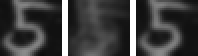

In [ ]:
# (1)フィルター変数の指定
kernel_size = 10
sigma = 1.0

# (2)フィルター処理
# img_gaussian = gaussian_filter(records[n].image, kernel_size, sigma)
# img_cossin_2axis = cossin_filter_2axis(records[n].image, kernel_size, sigma)
# img_cossin_radial = cossin_filter_radial(records[n].image, kernel_size, sigma)
img_gaussian = gaussian_filter(resize_image, kernel_size, sigma)
img_cossin_2axis = cossin_filter_2axis(resize_image, kernel_size, sigma)
img_cossin_radial = cossin_filter_radial(resize_image, kernel_size, sigma)

# (3)グリッドにまとめる
mosaic_filttering = mosaicview([img_gaussian, img_cossin_2axis, img_cossin_radial], nrow=1, ncol=3, npad=3, fillvalue=Gray(1.0))

# (4)表示
# imshow(img_gaussian)
# imshow(img_cossin_2axis)
# imshow(img_cossin_radial)
# display([img_gaussian img_cossin_2axis img_cossin_radial])
display(collect(mosaic_filttering))

# (5)保存
# save("etl1_gaussian.png", img_gaussian)
# save("etl1_cossin_2axis.png", img_cossin_2axis)
# save("etl1_cossin_radial.png", img_cossin_radial)
save("etl1_fittered.png", mosaic_filttering)

- `mosaicview()`の引数として画像（配列）を`[a b c]`で並べると1つの配列として扱い`ncol`に合わせて空白が入る。リスト`[a, b, c]` で指定する必要がある。

### 【参考】ETL1データフォーマット
https://etlcdb.db.aist.go.jp/etlcdb/etln/form_m.htm